# Advection-Reaction-Diffusion PDEs

## Time 0

In [1]:
import torch
from torch.utils.data import TensorDataset, ConcatDataset, Subset
from torch import Tensor
from data_utils import compute_prediction_difference, compute_prediction, extract_targets, extract_TensorDataset, X, U, TIMES
from plot_utils import plot_points, plot_loss_comp, plot_model_stats, print_model_info, plot_points_grid, plot_model_stats_grid, print_model_performances, plot_model_performances, get_animation
from load_store_utils import load_stats, resume_model
from train import start_train
from typing import List
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tqdm import tqdm
import numpy as np
# ----------------------
TRAIN = True
ONLY_FINAL_TRAINING = False
SAVE_PLOTS = True
CROSS_THE_RUBICON = True

PDE = "AdvectionReactionDiffusion/AllenCahn"
PDE_NAME = "Advection-Reaction-Diffusion"
SEED = 42

FIXED = ["IC", "D"]
IC_INDEX = 0
D_INDEX = 0
INDEX = 4
IC = 0 # only if all or nothing fixed
D = 0 # only if all or nothing fixed

N_SOURCES = 5

GENERATION_BC = "Neumann" # Dirichlet Neumann

TIME_INDEXES = [0, 1]
TIME_RESOLUTION = 1
TIME_SAMPLING = "Const" # Const Log

ACTUAL_MODE = "PINN" # Output Output+PINN Output+Derivative Output+Derivative+Hessian 
N_EPOCHS = 200
LR_MODE = "CosAnn" # CosAnn ExpDec

#SHAPE = {"shape": "circle", "cell_size": 0.02, "center": [0.0, 0.0], "radius": 1.0}
SHAPE = {"shape": "rectangle"}

BC_MODE = "Global" # Joined LocalFull
IC_MODE = "Separated"
TRAIN_BC = "Neumann" # Dirichlet Neumann
PDE_AT_BD = False
PDE_AT_T0 = True

FOURIER_FEATURES = False
IC_PARAMS_IN_INPUT = False
PDE_PARAMS_IN_INPUT = False

DWA_MODE = "Std"
CLIP_GRAD = True

# ----------------------

if "PINN" not in ACTUAL_MODE:
    MONITOR_CONFLICTS = False
else:
    MONITOR_CONFLICTS = True

if not CLIP_GRAD:
    CLIP = "NoGradClip"
else:
    CLIP = "GradClip"

if "IC" in FIXED and "D" in FIXED:
    if IC == D:
        DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/ICD{INDEX}"
        s = "VaryIC_VaryD"
        IC_INDEX = None
        D_INDEX = None
    elif IC < D:
        DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/IC{IC_INDEX}_D{D_INDEX}"
        s = "FixIC_VaryD"
        INDEX = D_INDEX
    else:
        DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/D{D_INDEX}_IC{IC_INDEX}"
        s = "VaryIC_FixD"
        INDEX = IC_INDEX
elif "IC" not in FIXED and "D" not in FIXED:
    DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/VaryIC_VaryD"
    s = "VaryIC_VaryD"
    IC_INDEX = None
    D_INDEX = None
    INDEX = None
elif "IC" in FIXED:
    DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/IC{IC_INDEX}_VaryD"
    s = "FixIC_VaryD"
    D_INDEX = None
    INDEX = None
else: # "D" in FIXED:
    DIR = f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/VaryIC_D{D_INDEX}"
    s = "VaryIC_FixD"
    IC_INDEX = None
    INDEX = None

os.makedirs(f"{PDE}/TimeIncrementalLearning/{DIR}", exist_ok=True)

if PDE_PARAMS_IN_INPUT and IC_PARAMS_IN_INPUT:
    DIR += f"/PDE_IC_params_in_input"
elif PDE_PARAMS_IN_INPUT:
    DIR += f"/PDE_params_in_input"
elif IC_PARAMS_IN_INPUT:
    DIR += f"/IC_params_in_input"
else:
    DIR += f"/No_params_in_input"

DIR += f"/{SHAPE['shape']}"
os.makedirs(f"{PDE}/TimeIncrementalLearning/{DIR}", exist_ok=True)

DIR += f"/T0"
os.makedirs(f"{PDE}/TimeIncrementalLearning/{DIR}", exist_ok=True)

if N_SOURCES is not None:
    s += f"/{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_0-9"
else:
    s += f"/{TIME_SAMPLING}TimeStep"

if "IC" not in FIXED and "D" not in FIXED:
    s += f"/rep0"
elif "IC" in FIXED and "D" in FIXED:
    if IC == D:
        s += f"/rep0"
    elif IC < D:
        s += f"/rep{IC_INDEX}"
    else:
        s += f"/rep{D_INDEX}"
elif "IC" in FIXED:
    s += f"/rep{IC_INDEX}"
elif "D" in FIXED:
    s += f"/rep{D_INDEX}"

BATCH_SIZE_TRAIN = 1024
BATCH_SIZE_DEV = 1024

DATA = f"data/{GENERATION_BC}BC/{SHAPE['shape']}/{s}"

full_dataset = None
dev_dataset = None
train_dataset = None
val_dataset = None
intra_test_dataset = None
inter_test_dataset = None

/home/claudia/tesi/ANN_fisica/code/code/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Functions

In [2]:
def load_subsets(
        dataset: List[ConcatDataset[TensorDataset]],
        indicesss: Tensor|List[List[Tensor]]
    ) -> List[ConcatDataset[Subset]]:
    datasetss = []
    for indicess, task_ds in zip(indicesss, dataset):
        datasets = []
        for indices, time_ds in zip(indicess, task_ds.datasets):
            datasets.append(Subset(time_ds, indices))
        datasetss.append(ConcatDataset(datasets))
    return datasetss

def load_datasets(
        dataset: List[ConcatDataset[TensorDataset]],
        indicesss: Tensor|List[List[Tensor]],
        time_resolution: int = 1
    ) -> List[ConcatDataset[TensorDataset]]:
    datasetss = []
    for cds, indicess in zip(dataset, indicesss):
        datasets = []
        for i in range(0, len(indicess), time_resolution):
            ds = cds.datasets[i]
            indices = indicess[i]
            cols = [col[indices] for col in ds.tensors]
            datasets.append(TensorDataset(*cols))
        datasetss.append(ConcatDataset(datasets))
    return datasetss

def merge_ds(datasets: List[TensorDataset]) -> TensorDataset:
    cols = None   
    for ds in datasets:
        new_cols = list(ds.tensors)
        if cols is None:
            cols = new_cols
        else:
            for i, col in enumerate(new_cols):
                cols[i] = torch.cat([cols[i], col])
    return TensorDataset(*cols)

def prepare_dataset(datasets: List[ConcatDataset], time_instants: List[int] = None) -> ConcatDataset:
    if time_instants is None:
        n_snapshots = len(datasets[0].datasets)
        time_instants = [i for i in range(n_snapshots)]
    data = []
    for i in time_instants:
        data.append(merge_ds([concat_ds.datasets[i] for concat_ds in datasets]))
    return ConcatDataset(data)

In [3]:
indices = {}
for s in ["dev", "train", "val", "intra_test"]:
    if INDEX is None:
        indices[s] = torch.load(f"{PDE}/{DATA}/{s}_indices.pth")
    else:
        indices[s] = [torch.load(f"{PDE}/{DATA}/{s}_indices.pth")[INDEX]]
    print(f"--------------- {s} set ---------------")
    print(f"n_tasks: {len(indices[s])}")
    print(f"time_instants_per_task: {len(indices[s][0])}")
    print(f"spatial_points_per_time_instant: {len(indices[s][0][0])}")

--------------- dev set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 2048
--------------- train set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 1536
--------------- val set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 512
--------------- intra_test set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 512


In [4]:
if INDEX is None:
    full_dataset = torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets
else:
    full_dataset = [torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets[INDEX]]

dev_dataset = load_datasets(full_dataset, indices["dev"])
del full_dataset
full_dataset = None

train_dataset = load_datasets(dev_dataset, indices["train"], TIME_RESOLUTION)
val_dataset = load_datasets(dev_dataset, indices["val"], TIME_RESOLUTION)
del dev_dataset
dev_dataset = None

print(f"time_instants: {TIME_INDEXES}")

train_dataset = prepare_dataset(datasets=train_dataset, time_instants=TIME_INDEXES)
val_dataset = prepare_dataset(datasets=val_dataset, time_instants=TIME_INDEXES)

print(f"train set size: {len(train_dataset)}")
print(f"val set size: {len(val_dataset)}")

time_instants: [0, 1]
train set size: 3072
val set size: 1024


### 1st model selection step
Perform 20 trials of 10 epochs each.

In [5]:
if TRAIN:
    models_dir = f"{PDE}/TimeIncrementalLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}{BC_MODE}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models0"
    
    n_sources = N_SOURCES
    pde_params = ["D"]
    ic_params = ["u0"]
    for i in range(n_sources):
        ic_params.append(f"xc{i}")
        ic_params.append(f"yc{i}")
        ic_params.append(f"amp{i}")
        ic_params.append(f"sigma{i}")
    
    actual = {
        "mode": ACTUAL_MODE,
        "time_in_input": True,
        "space_in_input": True,
        "shape": SHAPE,
        "importance": 1.0,
        "bc_importance": 1.0,
        "ic_importance": 1.0,
        "BC": TRAIN_BC,
        "boundary": BC_MODE,
        "pde_at_bd": PDE_AT_BD,
        "pde_at_t0": PDE_AT_T0,
        "initial_time": IC_MODE,
        "monitor_conflicts": MONITOR_CONFLICTS,
        "train_dataset": train_dataset,
        "val_dataset": val_dataset
    }
    if IC_PARAMS_IN_INPUT:
        actual["ic_params_in_input"] = ic_params
    if PDE_PARAMS_IN_INPUT:
        actual["pde_params_in_input"] = pde_params
    if FOURIER_FEATURES:
        actual["fourier_features"] = [-1, 5, 10, 20, 30]
        actual["frequency_variance"] = [1, 3, 5, 7, 9]
    else:
        actual["fourier_features"] = -1
        actual["frequency_variance"] = 1.0
    
    distill = {
        "mode": "Forgetting",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0
    }
    ewc = {
        "mode": "Off",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0
    }
    dwa = {
        "mode": DWA_MODE,
        "moving_avg_factor": 0.9,
        "moving_avg_frequency": 1,#10,
        "warm_up": 3
    }
    config_dict = {
        "PDE": PDE_NAME,
        "Actual": actual,
        "Distillation": distill,
        "EWC": ewc,
        "DWA": dwa,
        "pruner": "median",
        "n_warmup_steps": 3,
        "threshold": 1.0,
        "n_trials": 10,
        "epochs": 10,
        "eval_every": 1,
        "seed": SEED,
        "device": "cpu",
        "learning_rate": [1e-2, 1e-3, 1e-4],#[1e-3, 1e-4, 1e-5],
        "scheduler": LR_MODE,
        "clip_grad": CLIP_GRAD,
        "batch_size": min(BATCH_SIZE_TRAIN, len(train_dataset)),
        "models_dir": models_dir,
        "suggestions": "On"
    }
    if not ONLY_FINAL_TRAINING:
        start_train(config_dict)

[I 2026-04-13 17:31:25,370] A new study created in memory with name: no-name-d643aaf4-1da7-491a-9fb0-b4dbd8046720


batch_size_train = 1024
len(train_dataset) = 2048
batch_size_val = 988
len(val_dataset) = 988
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 118
len(train_bc_dataset) = 118
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 36
len(val_bc_dataset) = 36

Epoch: 0, step_prefix: 0
Epoch time: 0.6300675868988037
train weighted loss: 0.10581695288419724
train out loss: 0.08067839965224266
val weighted loss: 0.0946691557765007
val out loss: 0.08121814578771591

Epoch: 1, step_prefix: 2
Epoch time: 0.31877803802490234
train weighted loss: 0.14254999160766602
train out loss: 0.08259965479373932
val weighted loss: 0.12431769073009491
val out loss: 0.0821506604552269

Epoch: 2, step_prefix: 4
Epoch time: 0.2094576358795166
train weighted loss: 0.1717948466539383
train out loss: 0.07916916906833649
val weighted loss: 0.1458006203174591
val out loss: 0.07954179495573044

Epoch: 3, step_prefix: 6
Epoch time: 0.2926900386810303
train weighted loss: 0.

[I 2026-04-13 17:31:33,761] Trial 0 finished with value: 0.09730780984682497 and parameters: {'lr_init': 0.001}. Best is trial 0 with value: 0.09730780984682497.


val weighted loss: 0.19987481832504272
val out loss: 0.08442436158657074
batch_size_train = 1024
len(train_dataset) = 2048
batch_size_val = 988
len(val_dataset) = 988
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 118
len(train_bc_dataset) = 118
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 36
len(val_bc_dataset) = 36

Epoch: 0, step_prefix: 0
Epoch time: 0.3236997127532959
train weighted loss: 0.5535682737827301
train out loss: 0.09534288570284843
val weighted loss: 0.5051795244216919
val out loss: 0.0985361784696579

Epoch: 1, step_prefix: 2
Epoch time: 0.3038444519042969
train weighted loss: 0.4372086822986603
train out loss: 0.09214278683066368
val weighted loss: 0.36790263652801514
val out loss: 0.09349865466356277

Epoch: 2, step_prefix: 4
Epoch time: 0.2222003936767578
train weighted loss: 0.37077638506889343
train out loss: 0.08551521971821785
val weighted loss: 0.32466328144073486
val out loss: 0.08704143017530441

Epoch: 

[I 2026-04-13 17:31:39,786] Trial 1 finished with value: 0.09904744273080723 and parameters: {'lr_init': 0.01}. Best is trial 0 with value: 0.09730780984682497.


...

val weighted loss: 0.7412744164466858
val out loss: 0.1553930938243866
batch_size_train = 1024
len(train_dataset) = 2048
batch_size_val = 988
len(val_dataset) = 988
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 118
len(train_bc_dataset) = 118
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 36
len(val_bc_dataset) = 36

Epoch: 0, step_prefix: 0
Epoch time: 0.5000696182250977
train weighted loss: 0.7936936020851135
train out loss: 0.13143883645534515
val weighted loss: 0.6300872564315796
val out loss: 0.14009597897529602

Epoch: 1, step_prefix: 2
Epoch time: 0.21507954597473145
train weighted loss: 0.6717408001422882
train out loss: 0.11595234274864197
val weighted loss: 0.5161353349685669
val out loss: 0.12309517711400986

Epoch: 2, step_prefix: 4
Epoch time: 0.33686041831970215
train weighted loss: 0.6144762337207794
train out loss: 0.10824082419276237
val weighted loss: 0.4783022105693817
val out loss: 0.11358954012393951

Epoch: 3,

[I 2026-04-13 17:32:07,601] Trial 8 pruned. 


train weighted loss: 0.5879218280315399
train out loss: 0.10427714511752129
val weighted loss: 0.4817296266555786
val out loss: 0.10804387927055359
batch_size_train = 1024
len(train_dataset) = 2048
batch_size_val = 988
len(val_dataset) = 988
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 118
len(train_bc_dataset) = 118
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 36
len(val_bc_dataset) = 36

Epoch: 0, step_prefix: 0
Epoch time: 0.28013181686401367
train weighted loss: 0.9474055767059326
train out loss: 0.1312558650970459
val weighted loss: 0.7480932474136353
val out loss: 0.13991840183734894

Epoch: 1, step_prefix: 2
Epoch time: 0.347231388092041
train weighted loss: 0.770695686340332
train out loss: 0.11618633568286896
val weighted loss: 0.5870091915130615
val out loss: 0.12343050539493561

Epoch: 2, step_prefix: 4
Epoch time: 0.17717695236206055
train weighted loss: 0.6862640678882599
train out loss: 0.10855524241924286
val weig

[I 2026-04-13 17:32:10,006] Trial 9 pruned. 


val weighted loss: 0.5343113541603088
val out loss: 0.1084381490945816
Best trial params: {'lr_init': 0.001}
Best trial value: 0.09730780984682497
trialN0 --> trial0: Objective Value = 0.0973
trialN1 --> trial1: Objective Value = 0.0990
trialN2 --> trial2: Objective Value = 0.1066
trialN4 --> trial3: Objective Value = 0.1077
trialN3 --> trial4: Objective Value = 0.1884


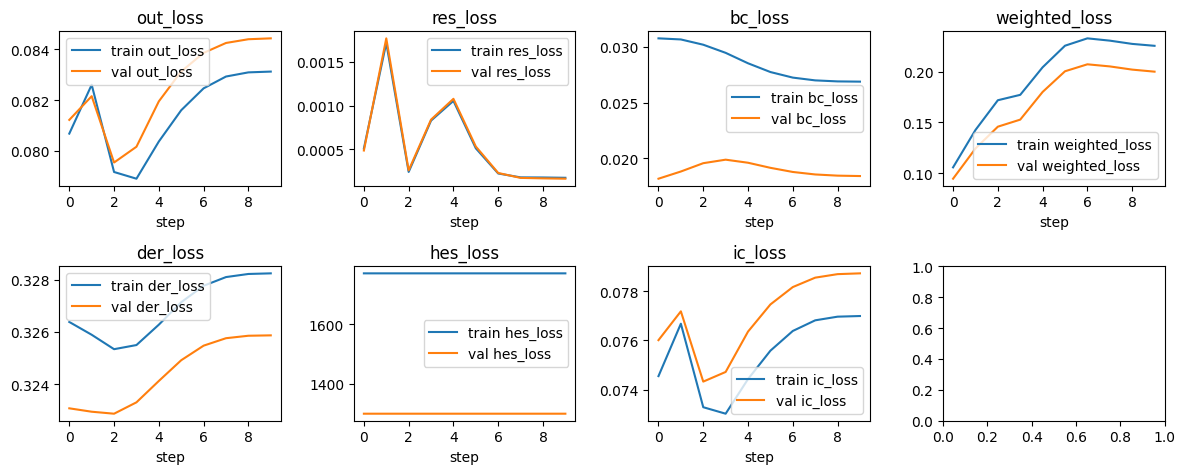


=============== Checkpoint ===============
PDE: Advection-Reaction-Diffusion
PDE parameters in input: []
Time in input: True
Space in input: True
Fourier features: -1
|Input units|: 3
Initial learning rate: 0.001
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Forgetting
	EWC: Off
	DWA: Std
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 3.347914934158325
	IC: 1.7399976253509521
	RES: 7.510725498199463
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 1.0
	OUT: 1.0
	DER: 1.0
	HES: 1.0
	EWC: 1.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importances:
--------------------

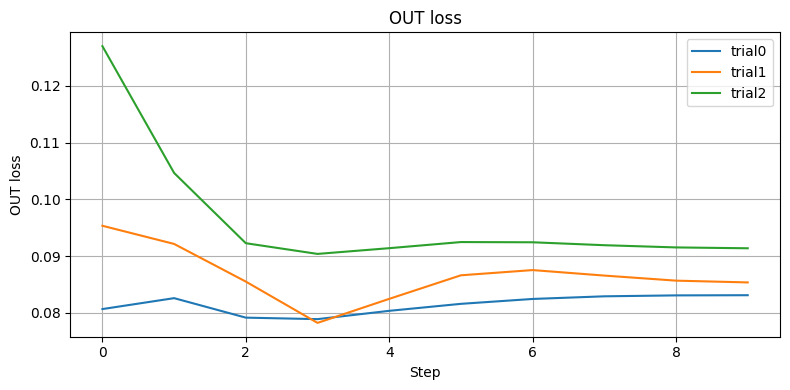

In [6]:
models_dir = f"{PDE}/TimeIncrementalLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}{BC_MODE}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models0"
os.makedirs(f"{models_dir}/plots", exist_ok=True)

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["train", "val"],
    subkeys=["out_loss", "der_loss", "res_loss", "hes_loss", "bc_loss", "ic_loss", "weighted_loss"],
    figsize=(12, 5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/losses.png"
)

print_model_info(f"{models_dir}/trial0")

models_dict = {
    "trial0": load_stats(f"{models_dir}/trial0"),
    "trial1": load_stats(f"{models_dir}/trial1"),
    "trial2": load_stats(f"{models_dir}/trial2")
}
plot_loss_comp(
    stats_dict=models_dict,
    phase="train",
    loss_prefix="out",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/loss_comp.png"
)

### 2nd model selection step
Take the best 3 trials/configurations and perform 50 epochs of training for each of them.

In [7]:
if TRAIN:
    n_best = 3
    models_dir = f"{PDE}/TimeIncrementalLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}{BC_MODE}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models0"
    
    fourier_features = []
    lr_init = []
    
    for i in range(n_best):
        checkpoint = torch.load(f"{models_dir}/trial{i}/model.pth", weights_only=False)
        fourier_features.append(checkpoint["fourier_features"])
        lr_init.append(checkpoint["lr_init"])
    
    models_dir = f"{PDE}/TimeIncrementalLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}{BC_MODE}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models1"
    
    config_dict["models_dir"] = models_dir
    config_dict["epochs"] = min(50, N_EPOCHS)
    config_dict["n_trials"] = 3
    config_dict["suggestions"] = "Off"
    config_dict["n_warmup_steps"] = 1000
    
    if FOURIER_FEATURES:
        actual["fourier_features"] = fourier_features
    config_dict["Actual"] = actual
    config_dict["learning_rate"] = lr_init
    if not ONLY_FINAL_TRAINING:
        start_train(config_dict)

[I 2026-04-13 17:32:12,630] A new study created in memory with name: no-name-4d9b40af-ebce-4082-b7a7-b26ad6217340


batch_size_train = 1024
len(train_dataset) = 2048
batch_size_val = 988
len(val_dataset) = 988
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 118
len(train_bc_dataset) = 118
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 36
len(val_bc_dataset) = 36

Epoch: 0, step_prefix: 0
Epoch time: 0.3961491584777832
train weighted loss: 0.10581695288419724
train out loss: 0.08067839965224266
val weighted loss: 0.0946691557765007
val out loss: 0.08121814578771591

Epoch: 1, step_prefix: 2
Epoch time: 0.24599552154541016
train weighted loss: 0.14331871271133423
train out loss: 0.08261538296937943
val weighted loss: 0.12498229742050171
val out loss: 0.08215545117855072

Epoch: 2, step_prefix: 4
Epoch time: 0.22427606582641602
train weighted loss: 0.17126000672578812
train out loss: 0.07895869016647339
val weighted loss: 0.14568445086479187
val out loss: 0.07941116392612457

Epoch: 3, step_prefix: 6
Epoch time: 0.33257365226745605
train weighted los

[I 2026-04-13 17:32:41,700] Trial 0 finished with value: 0.0928907746092591 and parameters: {}. Best is trial 0 with value: 0.0928907746092591.


val weighted loss: 0.17427024245262146
val out loss: 0.08213843405246735
batch_size_train = 1024
len(train_dataset) = 2048
batch_size_val = 988
len(val_dataset) = 988
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 118
len(train_bc_dataset) = 118
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 36
len(val_bc_dataset) = 36

Epoch: 0, step_prefix: 0
Epoch time: 0.36887550354003906
train weighted loss: 1.2331119775772095
train out loss: 0.0982007160782814
val weighted loss: 1.2478268146514893
val out loss: 0.10213368386030197

Epoch: 1, step_prefix: 2
Epoch time: 0.17601418495178223
train weighted loss: 1.0955356359481812
train out loss: 0.08001874387264252
val weighted loss: 1.0293877124786377
val out loss: 0.08166806399822235

Epoch: 2, step_prefix: 4
Epoch time: 0.23141908645629883
train weighted loss: 1.4678691625595093
train out loss: 0.08462289348244667
val weighted loss: 1.3570375442504883
val out loss: 0.08454970270395279

Epoch: 

[I 2026-04-13 17:33:09,784] Trial 1 finished with value: 0.059813375351950526 and parameters: {}. Best is trial 1 with value: 0.059813375351950526.


Epoch time: 0.2250964641571045
train weighted loss: 0.1475701481103897
train out loss: 0.05016598477959633
val weighted loss: 0.16400668025016785
val out loss: 0.05208231881260872
batch_size_train = 1024
len(train_dataset) = 2048
batch_size_val = 988
len(val_dataset) = 988
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 118
len(train_bc_dataset) = 118
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 36
len(val_bc_dataset) = 36

Epoch: 0, step_prefix: 0
Epoch time: 0.4056406021118164
train weighted loss: 1.468550443649292
train out loss: 0.1297396644949913
val weighted loss: 1.3675464391708374
val out loss: 0.1384250372648239

Epoch: 1, step_prefix: 2
Epoch time: 0.22353672981262207
train weighted loss: 0.6172548532485962
train out loss: 0.10832222178578377
val weighted loss: 0.47899341583251953
val out loss: 0.11554940044879913

Epoch: 2, step_prefix: 4
Epoch time: 0.3481900691986084
train weighted loss: 0.6110338568687439
train out lo

[I 2026-04-13 17:33:32,517] Trial 2 finished with value: 0.09451956812699791 and parameters: {}. Best is trial 1 with value: 0.059813375351950526.


train weighted loss: 0.26400026679039
train out loss: 0.08267548307776451
val weighted loss: 0.24398577213287354
val out loss: 0.08528468012809753
Best trial params: {}
Best trial value: 0.059813375351950526
trialN1 --> trial0: Objective Value = 0.0598
trialN0 --> trial1: Objective Value = 0.0929
trialN2 --> trial2: Objective Value = 0.0945


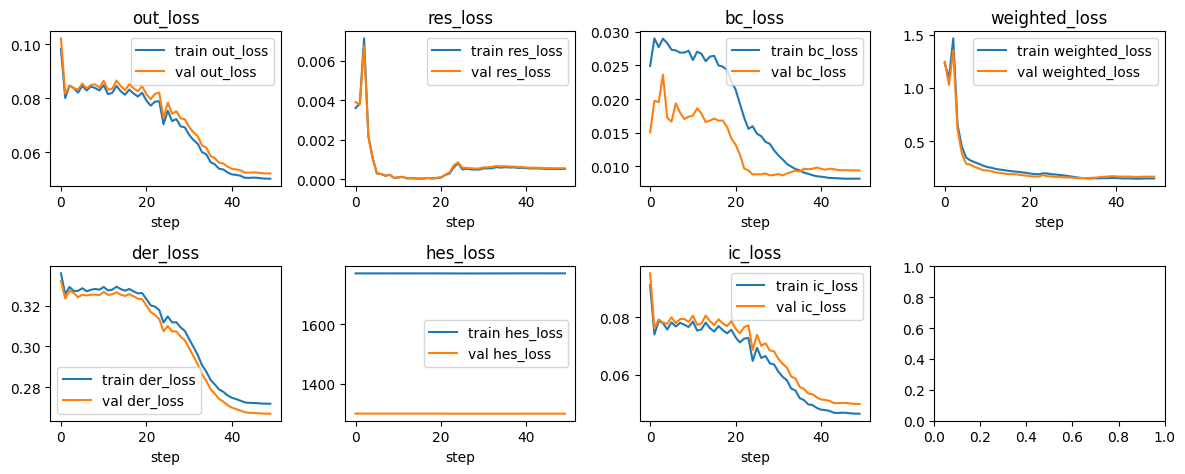


=============== Checkpoint ===============
PDE: Advection-Reaction-Diffusion
PDE parameters in input: []
Time in input: True
Space in input: True
Fourier features: -1
|Input units|: 3
Initial learning rate: 0.01
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Forgetting
	EWC: Off
	DWA: Std
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 9.310395240783691
	IC: 1.164819598197937
	RES: 32.78569412231445
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 1.0
	OUT: 1.0
	DER: 1.0
	HES: 1.0
	EWC: 1.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importances:
----------------------

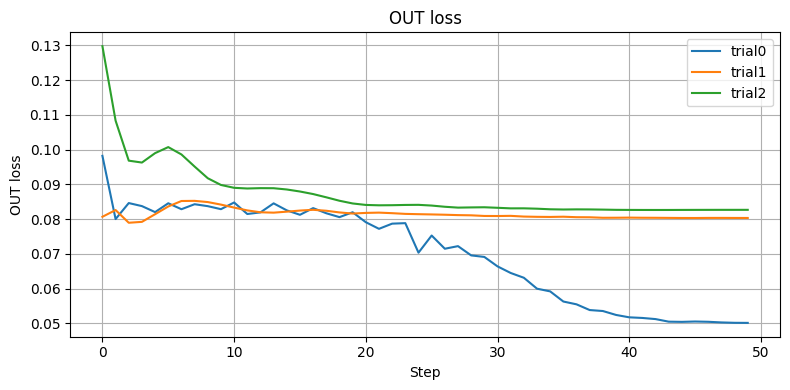

In [8]:
models_dir = f"{PDE}/TimeIncrementalLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}{BC_MODE}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models1"
os.makedirs(f"{models_dir}/plots", exist_ok=True)

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["train", "val"],
    subkeys=["out_loss", "der_loss", "res_loss", "hes_loss", "bc_loss", "ic_loss", "weighted_loss"],
    figsize=(12, 5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/losses.png"
)

print_model_info(f"{models_dir}/trial0")

models_dict = {
    "trial0": load_stats(f"{models_dir}/trial0"),
    "trial1": load_stats(f"{models_dir}/trial1"),
    "trial2": load_stats(f"{models_dir}/trial2")
}
plot_loss_comp(
    stats_dict=models_dict,
    phase="train",
    loss_prefix="out",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/loss_comp.png"
)

### 3rd model selection step
Take the best trial/configuration and perform 100 epochs of training.

In [9]:
if TRAIN:
    if train_dataset is not None:
        del train_dataset
        train_dataset = None
    if val_dataset is not None:
        del val_dataset
        val_dataset = None
    if INDEX is None:
        full_dataset = torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets
    else:
        full_dataset = [torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets[INDEX]]
    dev_dataset = load_datasets(full_dataset, indices["dev"], TIME_RESOLUTION)
    del full_dataset
    full_dataset = None
    
    dev_dataset = prepare_dataset(datasets=dev_dataset, time_instants=TIME_INDEXES)
    
    models_dir = f"{PDE}/TimeIncrementalLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}{BC_MODE}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models1"
    
    checkpoint = torch.load(f"{models_dir}/trial{0}/model.pth", weights_only=False)
    fourier_features = checkpoint["fourier_features"]
    lr_init = checkpoint["lr_init"]
    
    models_dir = f"{PDE}/TimeIncrementalLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}{BC_MODE}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
    
    config_dict["models_dir"] = models_dir
    config_dict["epochs"] = N_EPOCHS
    config_dict["n_trials"] = 1
    
    actual["fourier_features"] = fourier_features
    actual["train_dataset"] = dev_dataset
    actual["val_dataset"] = ""
    config_dict["Actual"] = actual
    config_dict["learning_rate"] = lr_init
    config_dict["batch_size"] = min(BATCH_SIZE_DEV, len(dev_dataset))
    start_train(config_dict)

[I 2026-04-13 17:33:39,209] A new study created in memory with name: no-name-ebabca27-1658-4fc3-b961-37dc3d23ce52


batch_size_train = 1024
len(train_dataset) = 3072
batch_size_train_ic = 1024
len(train_ic_dataset) = 2048
batch_size_train_bc = 154
len(train_bc_dataset) = 154

Epoch: 0, step_prefix: 0
Epoch time: 0.5623519420623779
train weighted loss: 0.22845615446567535
train out loss: 0.14606106777985892

Epoch: 1, step_prefix: 3
Epoch time: 0.4858512878417969
train weighted loss: 0.31520899136861164
train out loss: 0.10324079543352127

Epoch: 2, step_prefix: 6
Epoch time: 0.6625998020172119
train weighted loss: 0.3420708378156026
train out loss: 0.10097981492678325

Epoch: 3, step_prefix: 9
Epoch time: 0.43371129035949707
train weighted loss: 0.34058497349421185
train out loss: 0.09547671178976695

Epoch: 4, step_prefix: 12
Epoch time: 0.5161137580871582
train weighted loss: 0.3271976411342621
train out loss: 0.0885987455646197

Epoch: 5, step_prefix: 15
Epoch time: 0.42003417015075684
train weighted loss: 0.3039811849594116
train out loss: 0.0987825095653534

Epoch: 6, step_prefix: 18
Epoch time

[I 2026-04-13 17:35:38,541] Trial 0 finished with value: 0.006133668920180449 and parameters: {}. Best is trial 0 with value: 0.006133668920180449.


Best trial params: {}
Best trial value: 0.006133668920180449
trialN0 --> trial0: Objective Value = 0.0061


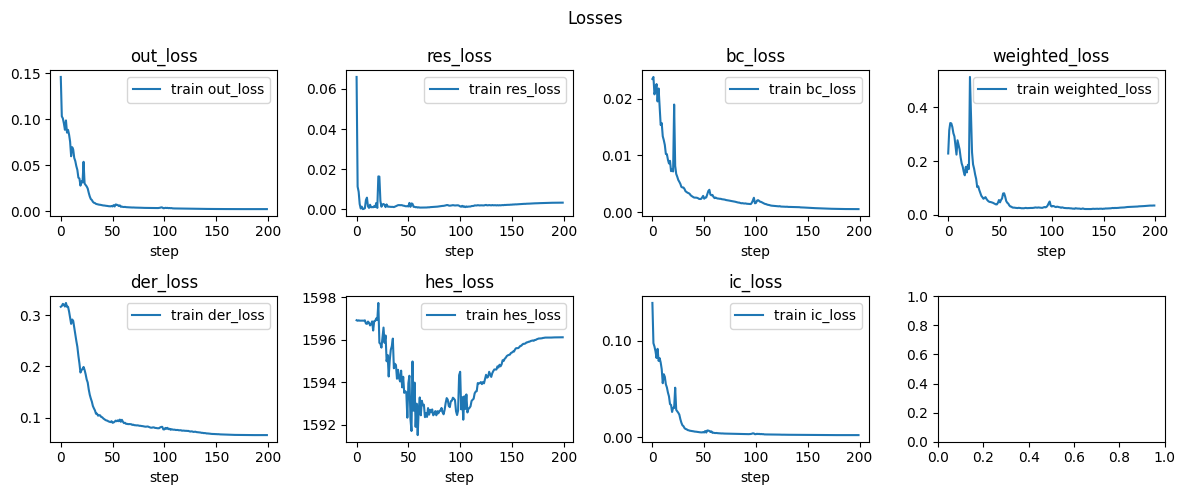


=============== Checkpoint ===============
PDE: Advection-Reaction-Diffusion
PDE parameters in input: []
Time in input: True
Space in input: True
Fourier features: -1
|Input units|: 3
Initial learning rate: 0.01
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Forgetting
	EWC: Off
	DWA: Std
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 26.699283599853516
	IC: 7.50140905380249
	RES: 1.2647546529769897
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 1.0
	OUT: 1.0
	DER: 1.0
	HES: 1.0
	EWC: 1.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importances:
---------------------

In [10]:
models_dir = f"{PDE}/TimeIncrementalLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}{BC_MODE}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
os.makedirs(f"{models_dir}/plots", exist_ok=True)

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["train"],
    subkeys=[
        "out_loss", 
        "der_loss", 
        "res_loss", 
        "hes_loss", 
        "bc_loss", 
        "ic_loss", 
        "weighted_loss"
        ],
    figsize=(12, 5),
    title="Losses",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/losses.png"
)

print_model_info(f"{models_dir}/trial0")

Last res_loss: 0.0033956272527575493
Last grad norm: 0.06379863619804382


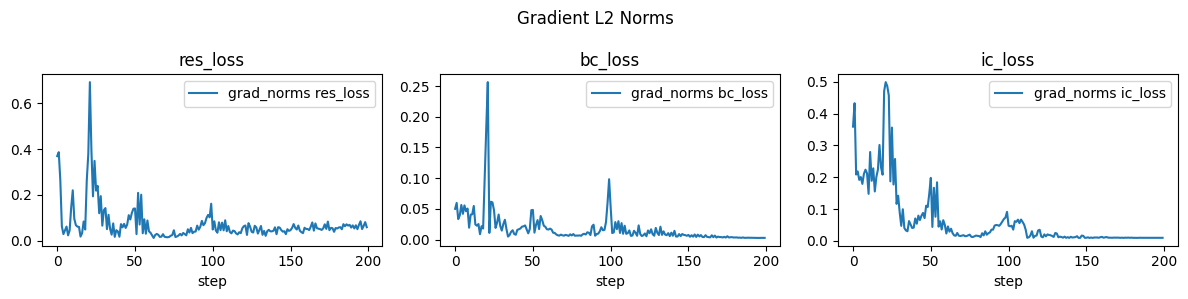

Last value weights res_loss: 1.2647546529769897
Last value weights bc_loss: 26.699283599853516
Last value weights ic_loss: 7.50140905380249


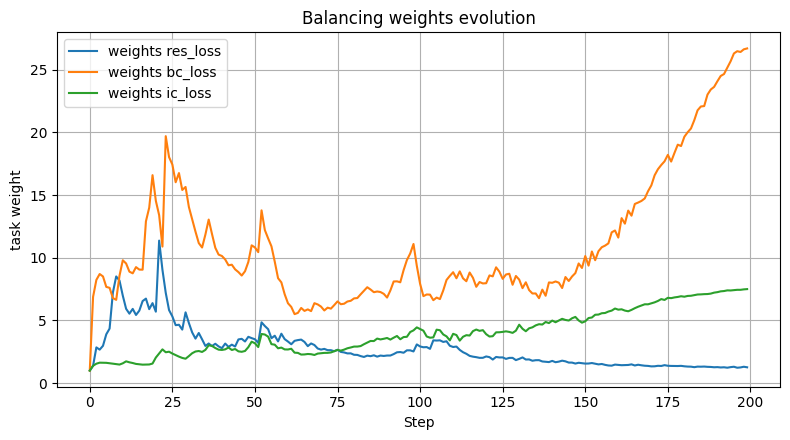

Last value conflicts bc_loss: -0.6818933486938477
Last value conflicts ic_loss: -0.6007474660873413


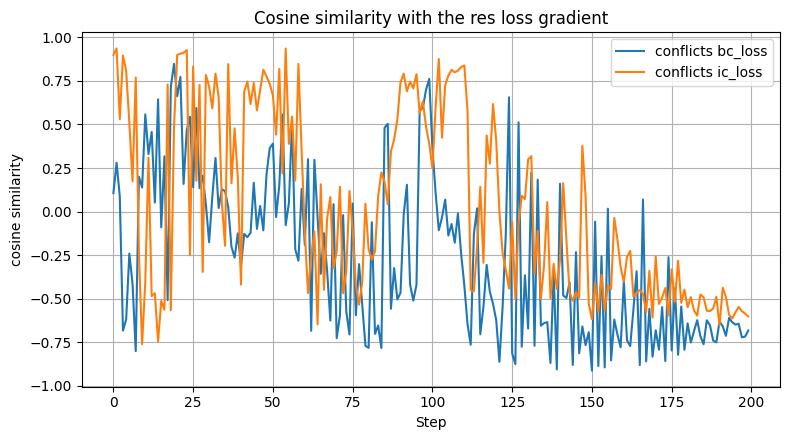

In [11]:
models_dir = f"{PDE}/TimeIncrementalLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}{BC_MODE}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
models_dict = {"trial0": load_stats(f"{models_dir}/trial0")}

print(f"Last res_loss: {models_dict['trial0']['train']['res_loss'][-1]}")
print(f"Last grad norm: {models_dict['trial0']['train_loss_grad_norm'][-1][0]}")

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["grad_norms"],
    subkeys=["res_loss", "bc_loss", "ic_loss"],
    figsize=(12, 3),
    title="Gradient L2 Norms",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/grad_norms.png"
)
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["weights"],
    subkeys=["res_loss", "bc_loss", "ic_loss"],
    ylabel="task weight",
    title="Balancing weights evolution",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/weights.png"
)
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["conflicts"],
    subkeys=["bc_loss", "ic_loss"],
    ylabel="cosine similarity",
    title="Cosine similarity with the res loss gradient",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/conflicts.png"
)

### Predictions vs real values

Params 4


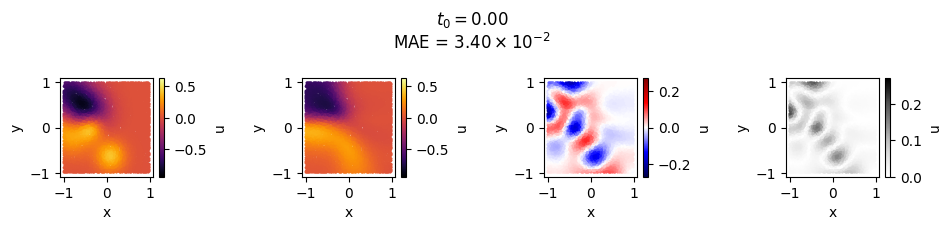

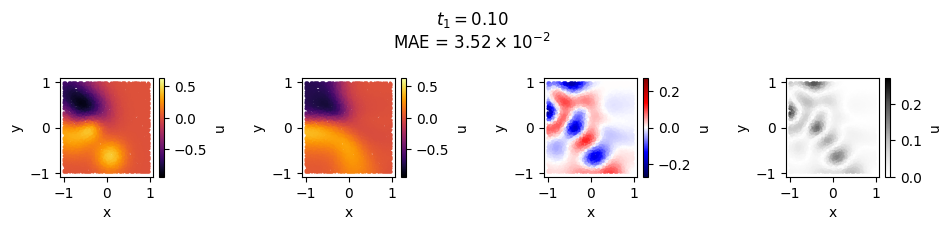

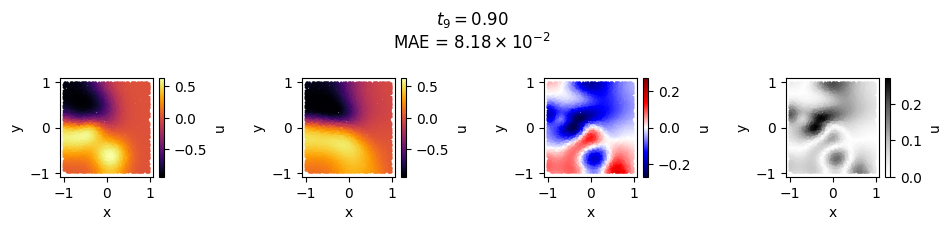

In [12]:
if CROSS_THE_RUBICON:
    times = [0, 1, 9]
    param_indices = [0, 1, 2] # [D_INDEX] [IC_INDEX]

    if "IC" in FIXED and "D" in FIXED:
        param_indices = [INDEX]

    if dev_dataset is not None:
        del dev_dataset
        dev_dataset = None
    datasets = torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets

    trues = [[[] for t in range(max(times)+1)] for i in range(max(param_indices)+1)]
    
    for i in param_indices:
        trues[i] = datasets[i].datasets
    del datasets

    models_dir = f"{PDE}/TimeIncrementalLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}{BC_MODE}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)

    best_model = resume_model(model_path=f"{models_dir}/trial0/model.pth", device="cpu")

    vmins = []
    vmaxs = []

    for i in param_indices:
        vmins.append(min([trues[i][t].tensors[U].min() for t in times]))
        vmaxs.append(max([trues[i][t].tensors[U].max() for t in times]))
    vmin = min(vmins)
    vmax = max(vmaxs)

    differences = [[[] for t in range(max(times)+1)] for i in range(max(param_indices)+1)]

    for i in param_indices:
        for t in times:
            differences[i][t] = compute_prediction_difference(model=best_model, dataset=trues[i][t], signed=True)
            
    vmins = []
    vmaxs = []

    for i in param_indices:
        vmins.append(min([differences[i][t].tensors[U].min() for t in times]))
        vmaxs.append(max([differences[i][t].tensors[U].max() for t in times]))
    vmin_diff = min(vmins)
    vmax_diff = max(vmaxs)
    v_diff = max(abs(vmin_diff), abs(vmax_diff))

    figsize = (9.8, 2.3)
    
    for i in param_indices:
        print(f"Params {i}")
        for t in times:

            prediction = compute_prediction(model=best_model, dataset=trues[i][t])
            abs_difference = compute_prediction_difference(model=best_model, dataset=trues[i][t], signed=False)
            mean_abs_difference = torch.mean(abs_difference.tensors[U])
            mae = mean_abs_difference.item()

            value = format(mae, ".2e").split('e')[0]
            exponent = format(mae, ".2e").split('e')[1]

            plot_points(
                dataset=[trues[i][t], prediction, differences[i][t], abs_difference],
                points_idx=X,
                labels_idx=U,
                cmap=["inferno", "inferno", "seismic", "Greys"],
                figsize=figsize,
                vmin=2*[vmin]+[-v_diff]+[0],
                vmax=2*[vmax]+[v_diff]+[v_diff],
                title=f"$t_{{{t}}} = {{{trues[i][t].tensors[TIMES][0].item():.2f}}}$\nMAE = ${{{value}}} \\times 10^{{{int(exponent)}}}$",
                save=True,
                dst_file=f"{models_dir}/plots/Task{i}Time{t}.png",
                show=True
            )

In [13]:
if CROSS_THE_RUBICON and False:
    param_indices = [0, 1, 2] # [D_INDEX] [IC_INDEX]

    if "IC" in FIXED and "D" in FIXED:
        param_indices = [INDEX]

    if dev_dataset is not None:
        del dev_dataset
        dev_dataset = None
    dataset = torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets
    dataset = [dataset[i] for i in param_indices]

    models_dir = f"{PDE}/TimeIncrementalLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}{BC_MODE}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)

    best_model = resume_model(model_path=f"{models_dir}/trial0/model.pth", device="cpu")

    for j, cds in tqdm(zip(param_indices, dataset), total=len(param_indices)):
        trues = []
        predictions = []
        differences = []
        for i in range(0, len(cds.datasets)):
            ds = cds.datasets[i]
            trues.append(ds)
            predictions.append(compute_prediction(model=best_model, dataset=ds))
            differences.append(compute_prediction_difference(model=best_model, dataset=ds, signed=False))
        get_animation(dataset=ConcatDataset(trues), figsize=(2, 1.5), filename=f"{models_dir}/plots/true{j}a.gif", save=True)
        get_animation(dataset=ConcatDataset(predictions), figsize=(2, 1.5), filename=f"{models_dir}/plots/predicted{j}a.gif", save=True)
        get_animation(dataset=ConcatDataset(differences), figsize=(2, 1.5), filename=f"{models_dir}/plots/difference{j}a.gif", save=True, cmap="Greys")

        #get_animation(dataset=ConcatDataset(trues[1:]), filename=f"{models_dir}/plots/true{j}b.gif", save=True)
        #get_animation(dataset=ConcatDataset(predictions[1:]), filename=f"{models_dir}/plots/predicted{j}b.gif", save=True)
        #get_animation(dataset=ConcatDataset(differences[1:]), filename=f"{models_dir}/plots/difference{j}b.gif", save=True, cmap="Greys")